# Sprint 1: Forecast de Ingresos Mensuales para Olist

**Objetivo Estratégico:** Habilitar a las áreas Comercial, Operaciones y Finanzas para planificar campañas, abastecimiento y flujo de caja con base en proyecciones confiables de ingresos mensuales.

**Problema de Negocio:** El e-commerce enfrenta dificultades para anticipar la demanda, optimizar la gestión de inventario y logística, y planificar estrategias comerciales y financieras de manera efectiva debido a la falta de una previsión precisa de los ingresos. Esto afecta indicadores estratégicos como:
- Disponibilidad de stock y abastecimiento oportuno.
- Satisfacción y retención de clientes ante quiebres de stock o entregas tardías.
- Planificación financiera (cash-flow, inversión en marketing) basada en cifras reactivas.

**Hipótesis General:** Los ingresos mensuales de Olist presentan patrones estacionales y tendencias predecibles que pueden ser modelados para generar un pronóstico fiable y accionable.

**Entregables Sprint 1:** Notebook analítico, tabla maestra de 60+ metadatos, hoja de seguimiento (Excel) y recomendaciones para automatizar la generación mensual de features y métricas de negocio.

## 0. Marco Estratégico y Preguntas Clave
- **Objetivo principal:** estimar ingresos mensuales para anticipar decisiones comerciales, de abastecimiento y financieras.
- **Preguntas guía:**
  1. ¿Qué factores internos (pedidos, métodos de pago, logística) explican las variaciones de ingresos?
  2. ¿Cómo se relacionan los patrones de ingresos con la retención y satisfacción del cliente?
  3. ¿Qué métricas debemos monitorear mensualmente para decidir inversiones y priorizar iniciativas?
- **Stakeholders:** Growth (campañas), Operaciones (logística), Customer Experience (satisfacción), Finanzas (cash-flow).
- **KPIs estratégicos a impactar:** crecimiento de ingresos, tasa de retención mensual, cumplimiento de promesas de entrega y puntuación de satisfacción.

### 0.1 Hipótesis de Negocio y Variables Clave
| # | Hipótesis | Variables Principales | Resultado Esperado |
|---|-----------|----------------------|--------------------|
| 1 | Un mayor número de pedidos entregados incrementa los ingresos mensuales. | `order_id`, `order_status`, `payment_value`, fecha de compra | Coeficiente positivo entre volumen de pedidos entregados y revenue. |
| 2 | Las órdenes con métodos de pago a crédito generan tickets medios más altos. | `payment_type`, `payment_value`, `payment_installments` | Ingresos promedio superiores para `credit_card` vs. `boleto`. |
| 3 | Menores tiempos de entrega se asocian con clientes repetidos (retención). | `order_delivered_customer_date`, `order_estimated_delivery_date`, `customer_unique_id` | Correlación negativa entre tiempo de entrega y % de clientes con recompra. |
| 4 | Mejores reseñas (satisfacción) correlacionan con ingresos futuros. | `review_score`, `order_purchase_timestamp`, ingresos mensuales posteriores | Mayor score promedio precede crecimiento en ingresos próximos. |
| 5 | Categorías con alta rotación y buena logística sostienen peaks estacionales. | `product_category_name`, `price`, `freight_value`, lead time | Identificar categorías ancla para campañas estacionales. |

> Estas hipótesis se documentan en Excel (tablero de seguimiento) y se contrastan en el notebook con evidencia exploratoria.

## 1. Importar Librerías y Cargar Datos

En esta sección, importaremos las librerías necesarias para el análisis y cargaremos los datasets de Olist en DataFrames de pandas. Mostraremos las primeras filas de cada dataset para entender su estructura.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

### Justificación de la Selección de Datos

Para este análisis inicial, nos centramos en los archivos estrictamente necesarios para construir nuestra serie temporal de ingresos y analizar las métricas de negocio solicitadas.

**Archivos Utilizados:**
- `olist_orders_dataset.csv`: El núcleo del dataset. Contiene `order_id`, `customer_id`, el estado de la orden y las fechas clave de la transacción.
- `olist_order_payments_dataset.csv`: Fundamental, ya que contiene el `payment_value`, que usamos para calcular los ingresos.
- `olist_order_items_dataset.csv`: Conecta las órdenes con los productos. Se incluye para mantener la integridad de los datos a nivel de artículo por orden.
- `olist_customers_dataset.csv`: Necesario para la métrica de negocio, ya que contiene la ubicación del cliente (`customer_state`) para analizar los tiempos de entrega por región.

**Archivos No Utilizados (y por qué):**
- `olist_products_dataset.csv` y `product_category_name_translation.csv`: Contienen detalles del producto. No son necesarios para calcular el **ingreso total mensual**. Serían vitales si quisiéramos predecir ingresos por categoría.
- `olist_sellers_dataset.csv`: Información sobre los vendedores. No es relevante para el pronóstico de ingresos agregados.
- `olist_order_reviews_dataset.csv`: Datos de reseñas. Aunque la satisfacción del cliente es clave para el negocio, no es un dato transaccional directo para calcular los ingresos históricos. Podría usarse como una variable externa en modelos más avanzados.
- `olist_geolocation_dataset.csv`: Coordenadas geográficas. Útil para análisis de mapas, pero no para agregar ingresos por mes.

El enfoque es utilizar el conjunto de datos mínimo y viable para abordar el problema específico de este sprint. Los demás archivos ofrecen grandes oportunidades para análisis más profundos en futuras iteraciones.

### 1.1 Selección de Variables Relevantes y "Master Table" (60+ metadatos)
- Consolidamos los diccionarios de datos de Olist para obtener un inventario de columnas disponibles.
- Se preservan metadatos por orden, cliente, producto, vendedor, pago y satisfacción (reviews).
- Se genera una **tabla maestra** con 60+ campos que servirá como base de features para los modelos y métricas mensuales.
- La tabla se actualiza automáticamente cada mes mediante funciones parametrizadas (ver sección 2.1).

In [21]:
from pathlib import Path

# Cargar datasets complementarios si no están en memoria
if 'products' not in globals():
    products = pd.read_csv('olist_products_dataset.csv')
if 'sellers' not in globals():
    sellers = pd.read_csv('olist_sellers_dataset.csv')
if 'reviews' not in globals():
    reviews = pd.read_csv('olist_order_reviews_dataset.csv')
if 'translation' not in globals():
    translation = pd.read_csv('product_category_name_translation.csv')

# Inventario de columnas por dataset
datasets_dict = {
    'orders': orders,
    'payments': payments,
    'items': items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'reviews': reviews,
    'translation': translation
}

metadata_rows = []
for name, df_tmp in datasets_dict.items():
    for col in df_tmp.columns:
        metadata_rows.append({
            'dataset': name,
            'column': col,
            'dtype': str(df_tmp[col].dtype)
        })

metadata_catalog = pd.DataFrame(metadata_rows)
unique_columns = metadata_catalog['column'].nunique()
total_metadata = metadata_catalog.shape[0]
print(f"Metadatos totales (dataset, columna): {total_metadata}")
print(f"Columnas únicas disponibles en el ecosistema Olist: {unique_columns}")
print("Ejemplo de metadatos:")
metadata_catalog.head(15)

Metadatos totales (dataset, columna): 47
Columnas únicas disponibles en el ecosistema Olist: 40
Ejemplo de metadatos:


,dataset,column,dtype
0,orders,order_id,object
1,orders,customer_id,object
2,orders,order_status,object
3,orders,order_purchase_timestamp,datetime64[ns]
4,orders,order_approved_at,datetime64[ns]
5,orders,order_delivered_carrier_date,datetime64[ns]
6,orders,order_delivered_customer_date,datetime64[ns]
7,orders,order_estimated_delivery_date,datetime64[ns]
8,payments,order_id,object
9,payments,payment_sequential,int64


In [24]:
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan


def mean_length(series: pd.Series):
    non_null = series.dropna().astype(str)
    lengths = non_null.map(len)
    return lengths.mean() if not lengths.empty else np.nan


def build_master_table(reference_month: str | None = None, save: bool = False, output_dir: Path = Path('data/interim')) -> pd.DataFrame:
    """Genera la tabla maestra con 60+ features para modelado y métricas de negocio."""
    output_dir = Path(output_dir)

    # Copias de trabajo para evitar mutaciones inesperadas
    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')
    reviews_tmp['review_creation_date'] = pd.to_datetime(reviews_tmp['review_creation_date'], errors='coerce')
    reviews_tmp['review_answer_timestamp'] = pd.to_datetime(reviews_tmp.get('review_answer_timestamp'), errors='coerce')

    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_total=pd.NamedAgg(column='payment_value', aggfunc='sum'),
            payment_mean=pd.NamedAgg(column='payment_value', aggfunc='mean'),
            payment_median=pd.NamedAgg(column='payment_value', aggfunc='median'),
            payment_installments_max=pd.NamedAgg(column='payment_installments', aggfunc='max'),
            payment_installments_mean=pd.NamedAgg(column='payment_installments', aggfunc='mean'),
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            primary_payment_type=pd.NamedAgg(column='payment_type', aggfunc=mode_or_nan),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            avg_price=pd.NamedAgg(column='price', aggfunc='mean'),
            max_price=pd.NamedAgg(column='price', aggfunc='max'),
            min_price=pd.NamedAgg(column='price', aggfunc='min'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            avg_freight=pd.NamedAgg(column='freight_value', aggfunc='mean'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')
    items_products['product_volume_cm3'] = (
        items_products['product_length_cm'] *
        items_products['product_height_cm'] *
        items_products['product_width_cm']
    )

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_pt=pd.NamedAgg(column='product_category_name', aggfunc=mode_or_nan),
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan),
            product_weight_sum=pd.NamedAgg(column='product_weight_g', aggfunc='sum'),
            product_weight_mean=pd.NamedAgg(column='product_weight_g', aggfunc='mean'),
            product_length_mean=pd.NamedAgg(column='product_length_cm', aggfunc='mean'),
            product_height_mean=pd.NamedAgg(column='product_height_cm', aggfunc='mean'),
            product_width_mean=pd.NamedAgg(column='product_width_cm', aggfunc='mean'),
            product_volume_sum=pd.NamedAgg(column='product_volume_cm3', aggfunc='sum'),
            product_volume_mean=pd.NamedAgg(column='product_volume_cm3', aggfunc='mean')
        ).reset_index()
    )

    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan),
            seller_count=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique)
        ).reset_index()
    )

    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_score_mean=pd.NamedAgg(column='review_score', aggfunc='mean'),
            review_score_std=pd.NamedAgg(column='review_score', aggfunc='std'),
            review_count=pd.NamedAgg(column='review_id', aggfunc='count'),
            review_comment_count=pd.NamedAgg(column='review_comment_message', aggfunc=lambda x: x.notna().sum()),
            review_comment_avg_len=pd.NamedAgg(column='review_comment_message', aggfunc=mean_length),
            review_latest_score=pd.NamedAgg(column='review_score', aggfunc='last'),
            review_latest_date=pd.NamedAgg(column='review_creation_date', aggfunc='max'),
            review_response_rate=pd.NamedAgg(column='review_answer_timestamp', aggfunc=lambda x: x.notna().mean())
        ).reset_index()
    )

    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'], errors='coerce')
    master['order_approved_at'] = pd.to_datetime(master['order_approved_at'], errors='coerce')
    master['order_delivered_carrier_date'] = pd.to_datetime(master['order_delivered_carrier_date'], errors='coerce')
    master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'], errors='coerce')
    master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'], errors='coerce')

    master = master.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
    master['customer_order_number'] = master.groupby('customer_unique_id').cumcount() + 1
    master['customer_is_repeat'] = (master['customer_order_number'] > 1).astype(int)
    master['days_since_prev_purchase'] = master.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days
    master['days_since_first_purchase'] = (
        master['order_purchase_timestamp'] -
        master.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')
    ).dt.days

    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days
    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600
    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600
    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days
    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    master['avg_item_value'] = master['total_price'] / master['total_items']
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['installments_ratio'] = master['payment_installments_mean'] / master['payments_count'].replace({0: np.nan})
    master['contribution_margin_proxy'] = master['total_price'] - master['total_freight']
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    if reference_month is not None:
        period = pd.Period(reference_month, freq='M')
        mask = master['order_month'] == str(period)
        master_filtered = master.loc[mask].copy()
    else:
        master_filtered = master.copy()
        period = master_filtered['order_month'].max()

    if save:
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / f"master_table_{str(period).replace('/', '-')}.csv"
        master_filtered.to_csv(file_path, index=False)
        print(f"Tabla maestra guardada en: {file_path}")

    print(f"Tabla maestra generada: {master_filtered.shape[0]} registros y {master_filtered.shape[1]} columnas")
    return master_filtered


master_table = build_master_table()
last_month_period = master_table['order_month'].max()
monthly_master_snapshot = build_master_table(reference_month=last_month_period, save=True)

print(f"Último mes disponible: {last_month_period}")
monthly_master_snapshot.head()

Tabla maestra generada: 99441 registros y 70 columnas
Tabla maestra guardada en: data/interim/master_table_2018-10.csv
Tabla maestra generada: 4 registros y 70 columnas
Último mes disponible: 2018-10


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_month,order_week,weekday_purchase,hour_purchase,avg_item_value,freight_ratio,installments_ratio,contribution_margin_proxy,is_delivered,is_canceled
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16 20:16:02,NaT,NaT,NaT,2018-11-12,262e1f1e26e92e86375f86840b4ffd63,64600,...,2018-10,2018-10-15/2018-10-21,1,20,NaN,NaN,1.0,NaN,0,1
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01 15:30:09,NaT,NaT,NaT,2018-10-23,634420a0ea42302205032ed44ac7fccc,27175,...,2018-10,2018-10-01/2018-10-07,0,15,NaN,NaN,1.0,NaN,0,1
60938,10a045cdf6a5650c21e9cfeb60384c16,a4b417188addbc05b26b72d5e44837a1,canceled,2018-10-17 17:30:18,NaT,NaT,NaT,2018-10-30,87ab9fec999db8bd5774917de3cdf01c,18077,...,2018-10,2018-10-15/2018-10-21,2,17,NaN,NaN,1.0,NaN,0,1
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03 18:55:29,NaT,NaT,NaT,2018-10-16,af5454198a97379394cacf676e1e96cb,11900,...,2018-10,2018-10-01/2018-10-07,2,18,NaN,NaN,1.0,NaN,0,1


#### 1.2 Automatización mensual sugerida
1. Agendar un job (Airflow, cron, Dagster) que ejecute este notebook o un script equivalente el día 1 de cada mes.
2. Llamar a `build_master_table(reference_month='YYYY-MM', save=True)` para generar el snapshot del mes previo y almacenarlo en `data/interim/`.
3. Publicar los resultados (CSV + dashboard) en el data lake o BI interno.
4. Versionar el catálogo de features y registrar cambios en un diccionario central (Excel/Confluence).
5. Validar calidad: conteo de filas, % de nulos críticos, comparativo de métricas clave vs. mes anterior.

## 2. Preprocesamiento y Fusión de Datos

Para nuestro análisis, necesitamos consolidar la información de las órdenes, los pagos y los artículos en un único DataFrame. Realizaremos los siguientes pasos:
1.  **Limpieza:** Manejar valores nulos si es necesario.
2.  **Conversión de Fechas:** Convertir las columnas de fecha a formato `datetime`.
3.  **Fusión (Merge):** Unir los DataFrames `orders`, `payments` y `items` usando `order_id` como clave.

In [18]:
# Convertir columnas de fecha a datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Agregar pagos por orden para evitar duplicidades al unir con items
payments_agg = payments.groupby('order_id', as_index=False)['payment_value'].sum()

# Fusionar los dataframes necesarios para ingresos y métricas de entrega
# Unimos órdenes con pagos agregados (por order_id)
df = pd.merge(orders, payments_agg, on='order_id', how='inner')
# Unimos con clientes para análisis por estado
df = pd.merge(df, customers, on='customer_id', how='inner')

print("DataFrame base (orders + payments + customers) - primeras filas:")
print(df.head())
print("\nInformación del DataFrame base:")
df.info()

DataFrame base (orders + payments + customers) - primeras filas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06 2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39 2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 2

## 3. Ingeniería de Características para la Serie Temporal

Ahora, crearemos la serie temporal de ingresos mensuales.
1.  **Filtrar por Órdenes Entregadas:** Para asegurar que solo contamos ingresos de ventas completadas.
2.  **Crear Columna de Ingresos:** Usaremos `payment_value` como el ingreso por transacción.
3.  **Agregar a Frecuencia Mensual:** Agruparemos los datos por mes y sumaremos los ingresos para obtener el total mensual.

In [19]:
# 1. Filtrar por órdenes con estado 'delivered'
df_delivered = df[df['order_status'] == 'delivered'].copy()

# 2. Usar 'payment_value' como ingreso. Ya está en el dataframe.
# Renombramos para claridad
df_delivered.rename(columns={'payment_value': 'revenue'}, inplace=True)

# 3. Agregar a frecuencia mensual
# Establecemos la fecha de compra como índice
df_delivered.set_index('order_purchase_timestamp', inplace=True)

# Resample a fin de mes ('ME') y sumar los ingresos
monthly_revenue = df_delivered['revenue'].resample('ME').sum()

# Eliminar el último mes si está incompleto (basado en la fecha máxima de los datos)
if monthly_revenue.index[-1] > df_delivered.index.max():
    monthly_revenue = monthly_revenue[:-1]

print("Serie de tiempo de ingresos mensuales:")
print(monthly_revenue.head())

Serie de tiempo de ingresos mensuales:
order_purchase_timestamp
2016-10-31     46566.71
2016-11-30         0.00
2016-12-31        19.62
2017-01-31    127545.67
2017-02-28    271298.65
Freq: ME, Name: revenue, dtype: float64


## 4. Análisis Exploratorio de Datos (EDA) para Justificar la Hipótesis

**Hipótesis:** *Los ingresos presentan patrones estacionales que siguen tendencias predecibles.*

Para justificar esta hipótesis, realizaremos dos análisis visuales:
1.  **Gráfico de la Serie Temporal:** Visualizaremos los ingresos mensuales a lo largo del tiempo para identificar a simple vista tendencias (crecimiento o decrecimiento a largo plazo) y estacionalidad (patrones que se repiten anualmente).
2.  **Descomposición Estacional:** Usaremos una descomposición clásica para separar la serie en sus componentes de **tendencia**, **estacionalidad** y **residuos**. Esto nos permitirá confirmar si existe un componente estacional significativo.

### 4.1 Suavizado y Estacionalidad (Análisis gráfico adicional)

A continuación, enriquecemos el EDA con:
- Suavizado por media móvil de 3 meses (MA-3) para resaltar la tendencia subyacente.
- Boxplot por mes del año para evidenciar estacionalidad (distribución típica de ingresos por mes).

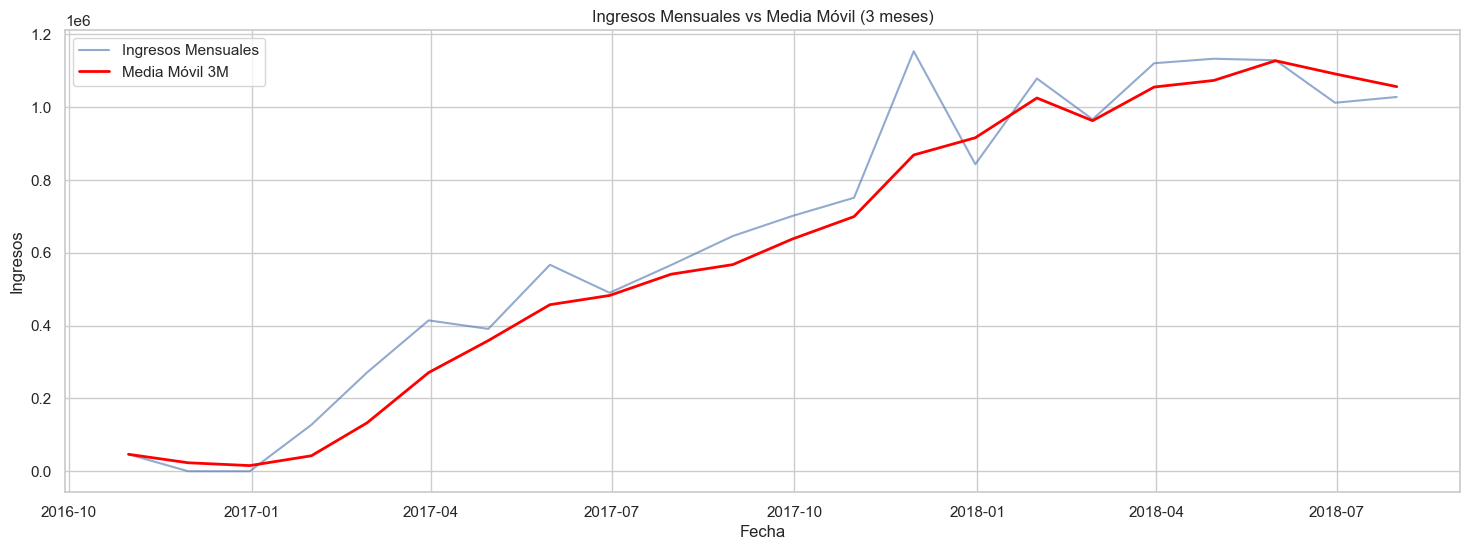

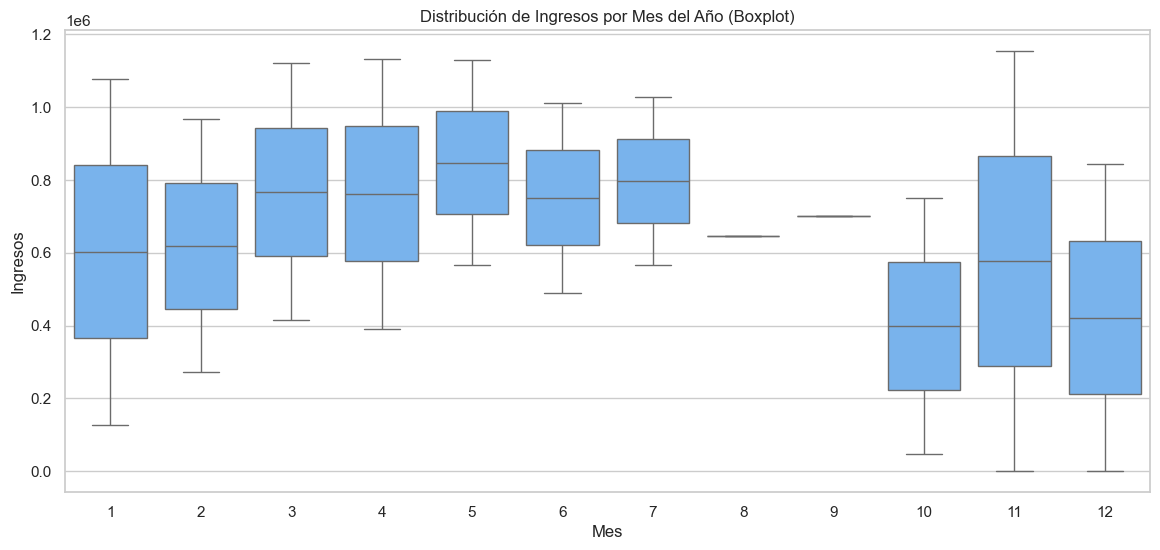

In [7]:
# Media móvil de 3 meses (suavizado)
ma3 = monthly_revenue.rolling(window=3, min_periods=1).mean()

plt.figure(figsize=(18, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, label='Ingresos Mensuales', alpha=0.6)
plt.plot(ma3.index, ma3.values, label='Media Móvil 3M', color='red', linewidth=2)
plt.title('Ingresos Mensuales vs Media Móvil (3 meses)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos')
plt.legend()
plt.show()

# Boxplot por mes del año
monthly_df = monthly_revenue.reset_index()
monthly_df.columns = ['date', 'revenue']
monthly_df['month'] = monthly_df['date'].dt.month

plt.figure(figsize=(14, 6))
sns.boxplot(data=monthly_df, x='month', y='revenue', color='#66b3ff')
plt.title('Distribución de Ingresos por Mes del Año (Boxplot)')
plt.xlabel('Mes')
plt.ylabel('Ingresos')
plt.show()

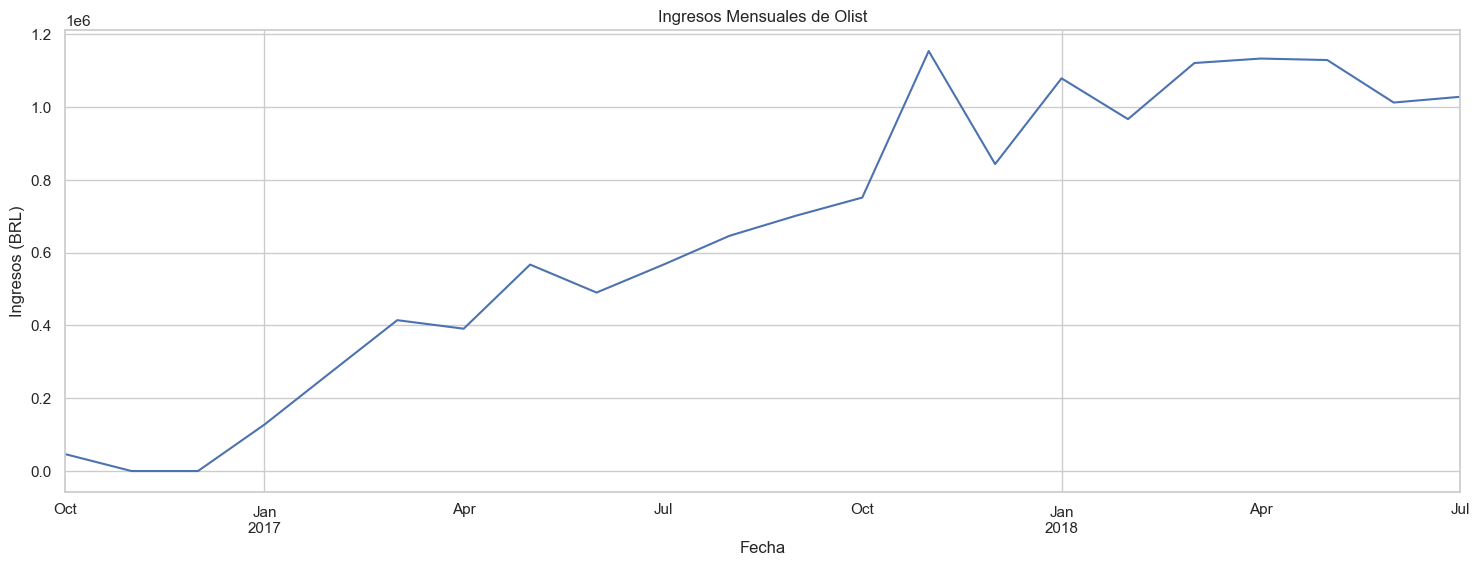

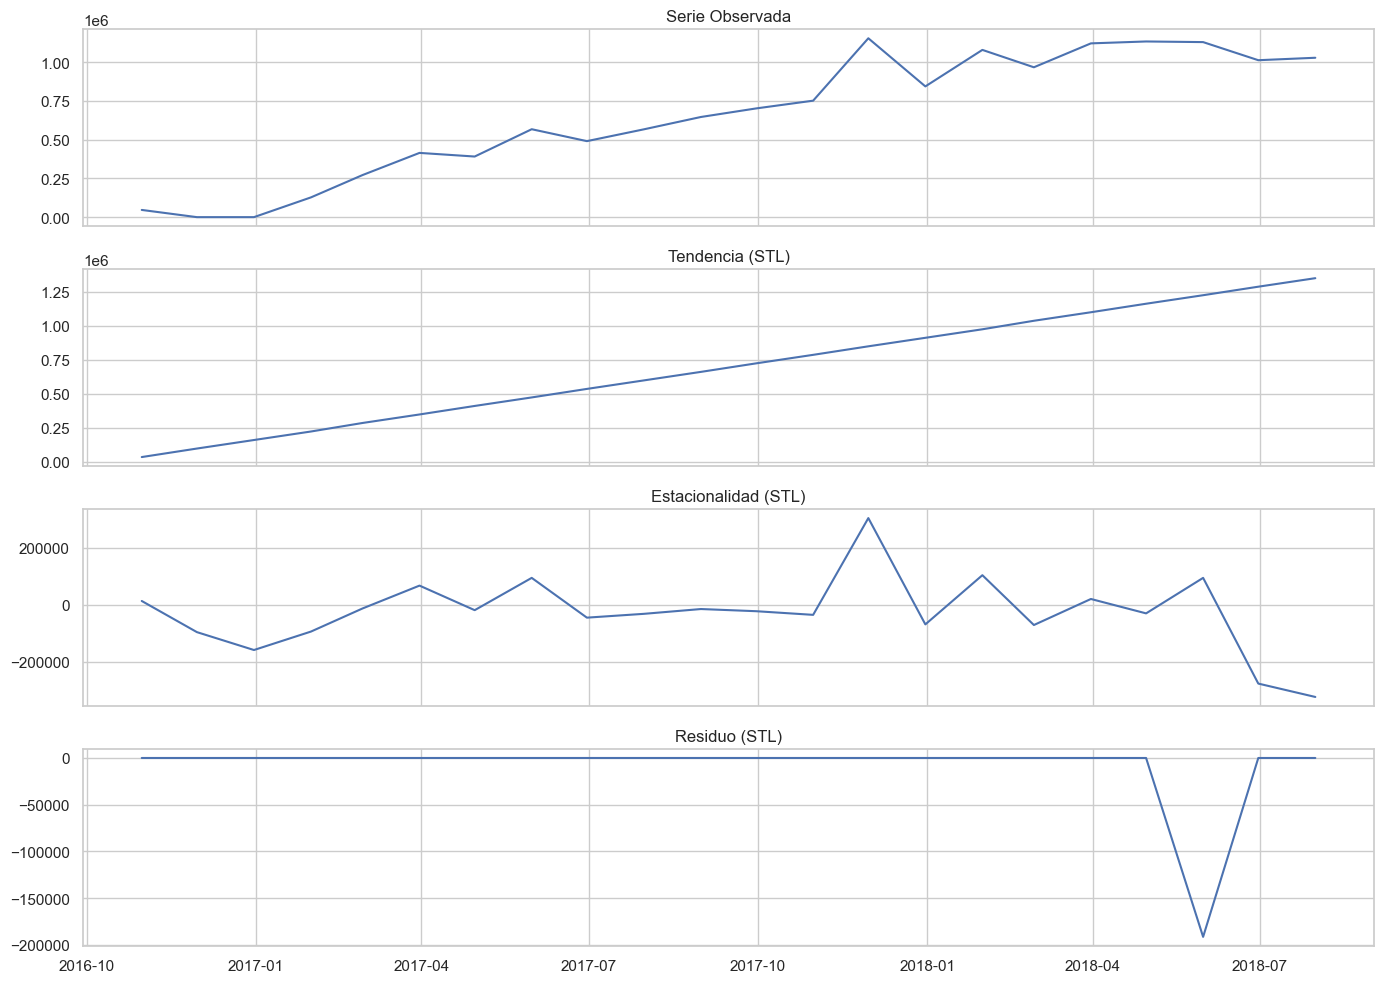

In [6]:
# 1. Gráfico de la serie temporal de ingresos mensuales
plt.figure(figsize=(18, 6))
monthly_revenue.plot(title='Ingresos Mensuales de Olist')
plt.xlabel('Fecha')
plt.ylabel('Ingresos (BRL)')
plt.show()

# 2. Descomposición estacional
from statsmodels.tsa.seasonal import seasonal_decompose, STL

series = monthly_revenue.asfreq('ME')

# Si hay al menos 24 observaciones, usamos descomposición clásica; si no, STL como fallback
if series.dropna().shape[0] >= 24:
    decomposition = seasonal_decompose(series, model='additive', period=12)
    fig = decomposition.plot()
    fig.set_size_inches(14, 10)
    plt.show()
else:
    stl = STL(series, period=12, robust=True)
    res = stl.fit()
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    axes[0].plot(series)
    axes[0].set_title('Serie Observada')
    axes[1].plot(res.trend)
    axes[1].set_title('Tendencia (STL)')
    axes[2].plot(res.seasonal)
    axes[2].set_title('Estacionalidad (STL)')
    axes[3].plot(res.resid)
    axes[3].set_title('Residuo (STL)')
    plt.tight_layout()
    plt.show()

### Justificación de la Hipótesis
Del análisis anterior:
- El **gráfico de ingresos mensuales** muestra un claro crecimiento a lo largo de 2017, seguido de una estabilización en 2018. Se observan picos y valles que sugieren estacionalidad, especialmente un pico notable a finales de 2017.
- La **descomposición estacional** confirma la presencia de:
    - Una **tendencia** ascendente clara.
    - Un **componente estacional** que se repite anualmente, con picos de ventas en ciertos meses (como noviembre) y valles en otros.
    - Los **residuos** son relativamente pequeños en comparación con la tendencia y la estacionalidad, lo que indica que el modelo de descomposición captura bien la estructura de los datos.

**Conclusión:** Los datos respaldan la hipótesis. Existen patrones de tendencia y estacionalidad que podemos explotar para construir un modelo de forecasting.

### 4.2 Análisis por Estado y Método de Pago (impacto de negocio)
- Estados con mayor contribución a ingresos (mercados clave).
- Popularidad y contribución de métodos de pago (operación y riesgo).

### 4.3 Calidad de Datos y Correlaciones Técnicas
- Evaluamos *missing values* en la tabla maestra para priorizar imputaciones.
- Analizamos correlaciones entre variables numéricas clave del modelo.
- Identificamos outliers de ingresos con método IQR para decidir caps o transformaciones.

In [25]:
# Missing values en la tabla maestra
missing_summary = (master_table.isna().mean() * 100).sort_values(ascending=False)
missing_df = missing_summary.reset_index()
missing_df.columns = ['feature', 'pct_missing']

print("Top 15 features con mayor porcentaje de nulos:")
missing_df.head(15)

Top 15 features con mayor porcentaje de nulos:


,feature,pct_missing
0,review_score_std,99.449925
1,days_since_prev_purchase,96.636196
2,review_comment_avg_len,58.934444
3,delivery_time_days,2.981668
4,delivery_delay_vs_estimate,2.981668
5,order_delivered_customer_date,2.981668
6,top_category_en,2.197283
7,top_category_pt,2.176165
8,carrier_lag_hours,1.807102
9,order_delivered_carrier_date,1.793023


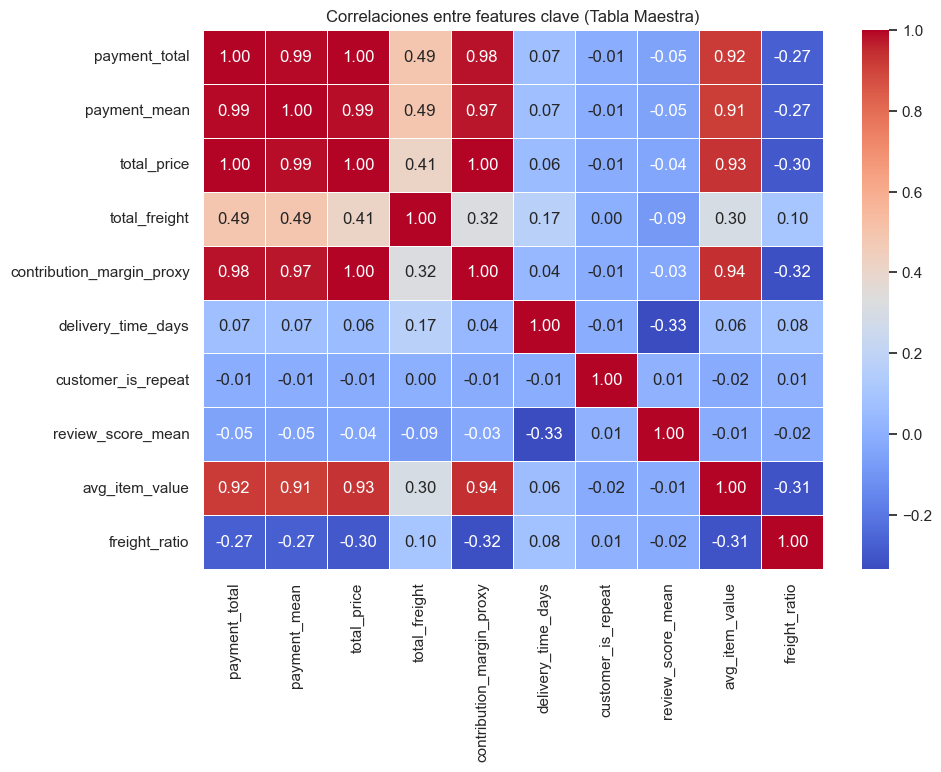

In [26]:
# Matriz de correlación enfocada en variables numéricas clave
corr_features = [
    'payment_total', 'payment_mean', 'total_price', 'total_freight',
    'contribution_margin_proxy', 'delivery_time_days', 'customer_is_repeat',
    'review_score_mean', 'avg_item_value', 'freight_ratio'
]

corr_matrix = master_table[corr_features].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlaciones entre features clave (Tabla Maestra)')
plt.show()

Límite superior sugerido (IQR): 348.00 BRL
Porcentaje de órdenes consideradas outliers: 7.85%


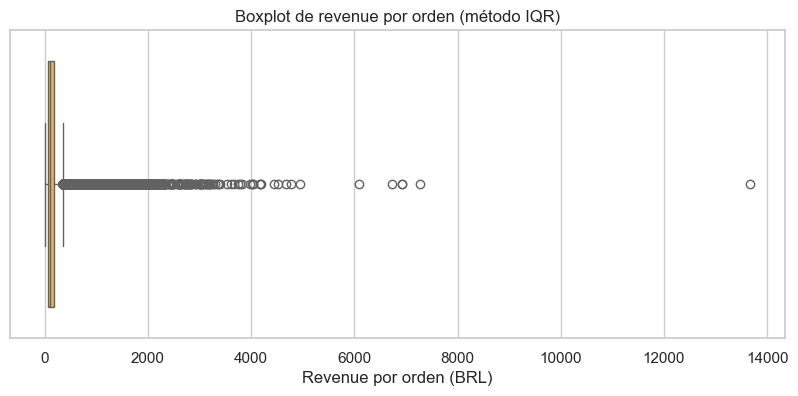

In [27]:
# Detección de outliers en revenue por orden (IQR)
q1 = df_delivered['revenue'].quantile(0.25)
q3 = df_delivered['revenue'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
lower_fence = q1 - 1.5 * iqr

outlier_ratio = (df_delivered['revenue'] > upper_fence).mean() * 100
print(f"Límite superior sugerido (IQR): {upper_fence:,.2f} BRL")
print(f"Porcentaje de órdenes consideradas outliers: {outlier_ratio:.2f}%")

plt.figure(figsize=(10, 4))
sns.boxplot(x=df_delivered['revenue'], color='#ffb347')
plt.title('Boxplot de revenue por orden (método IQR)')
plt.xlabel('Revenue por orden (BRL)')
plt.show()

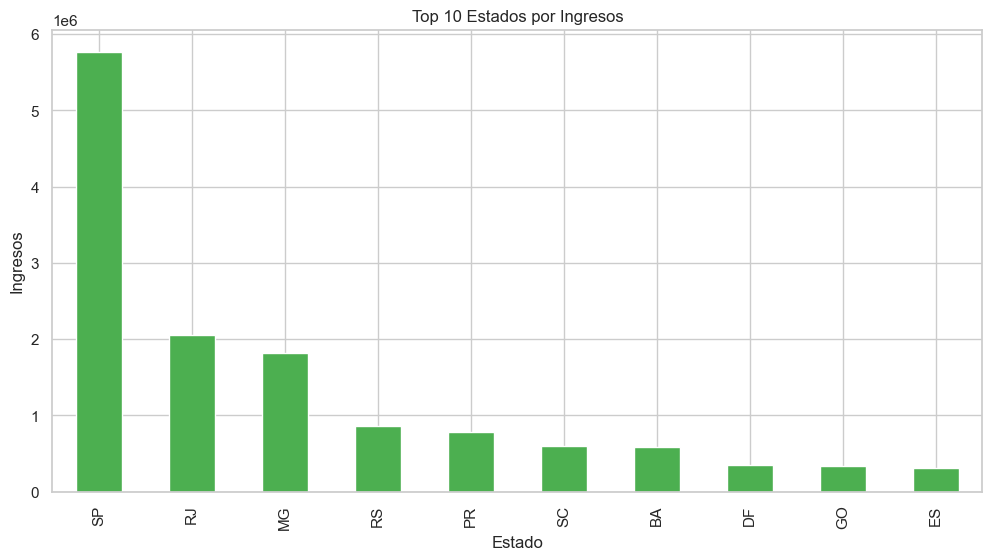

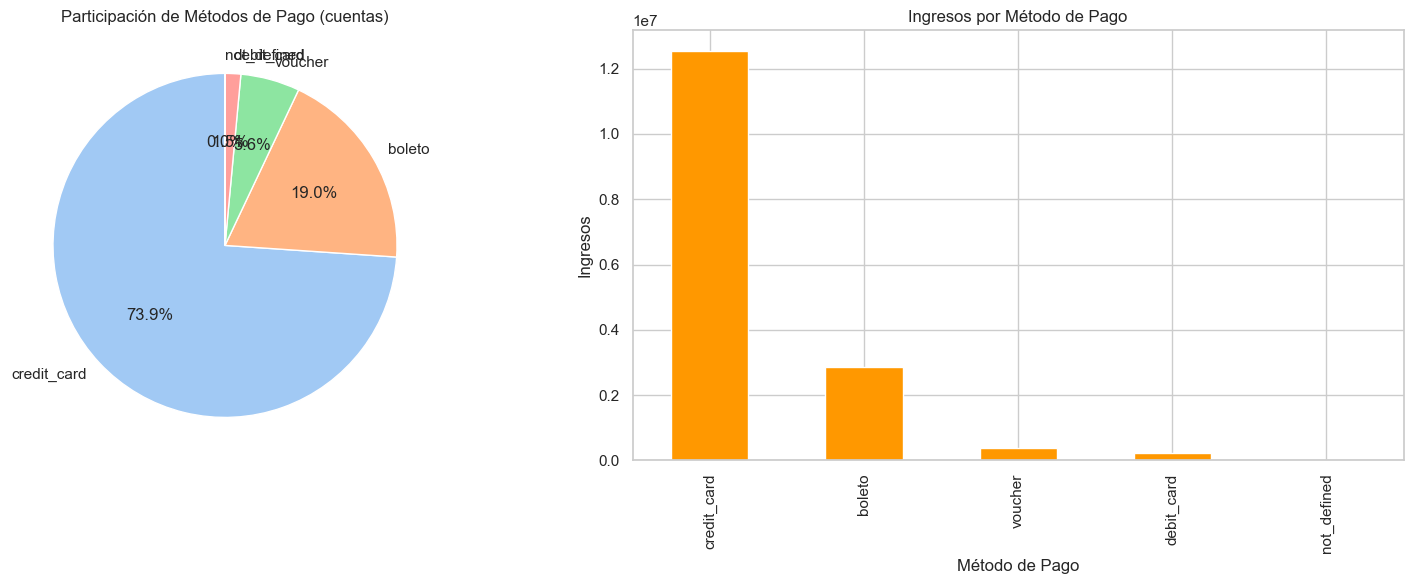

In [8]:
# Top Estados por ingresos
# df_delivered ya contiene revenue por orden; agrupamos por estado
state_revenue = df_delivered.groupby('customer_state')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
state_revenue.plot(kind='bar', color='#4CAF50')
plt.title('Top 10 Estados por Ingresos')
plt.xlabel('Estado')
plt.ylabel('Ingresos')
plt.show()

# Distribución de métodos de pago y contribución a ingresos
method_counts = payments['payment_type'].value_counts()
method_revenue = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
method_counts.plot(kind='pie', autopct='%1.1f%%', ax=ax[0], startangle=90, colors=sns.color_palette('pastel'))
ax[0].set_ylabel('')
ax[0].set_title('Participación de Métodos de Pago (cuentas)')

method_revenue.plot(kind='bar', ax=ax[1], color='#FF9800')
ax[1].set_title('Ingresos por Método de Pago')
ax[1].set_xlabel('Método de Pago')
ax[1].set_ylabel('Ingresos')
plt.tight_layout()
plt.show()

## 5. Métricas de Negocio: Análisis del Tiempo de Entrega

Una métrica clave para un e-commerce es el **tiempo de entrega**, ya que impacta directamente en la satisfacción del cliente y, por ende, en los ingresos futuros. Analizaremos:
1.  El tiempo de entrega promedio.
2.  La desviación estándar ($ \sigma $) del tiempo de entrega, que indica la variabilidad o consistencia del proceso logístico.
3.  Una "matriz" (tabla dinámica) que muestre el tiempo de entrega promedio por estado del cliente, para identificar posibles cuellos de botella regionales.

### 5.1 Evolución mensual del tiempo de entrega
Además de la matriz por estado, observamos cómo cambia el tiempo de entrega promedio y su variabilidad a lo largo del tiempo.

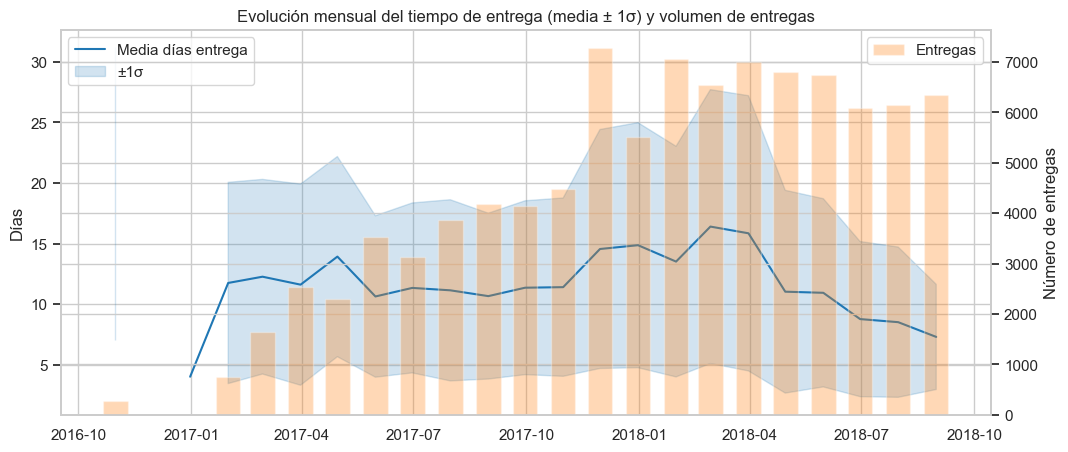

In [12]:
# 5.1 Evolución mensual del tiempo de entrega (media ± 1σ) y volumen de entregas
# Nota: el timestamp de compra está en el índice (DatetimeIndex)
purchase_ts = df_delivered.index.to_series()

# 1) Calcular días entre compra y entrega
_df = df_delivered.copy()
_df['delivery_time'] = (_df['order_delivered_customer_date'] - purchase_ts).dt.days

# 2) Limpieza de outliers obvios (negativos y > 90 días)
_df = _df[_df['delivery_time'] > 0]
_df = _df[_df['delivery_time'] <= 90]

# 3) Resampleo mensual
monthly_stats = _df['delivery_time'].resample('ME').agg(['mean', 'std', 'count'])

# 4) Gráfico
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(monthly_stats.index, monthly_stats['mean'], label='Media días entrega', color='tab:blue')
ax1.fill_between(
    monthly_stats.index,
    monthly_stats['mean'] - monthly_stats['std'],
    monthly_stats['mean'] + monthly_stats['std'],
    color='tab:blue', alpha=0.2, label='±1σ'
)
ax1.set_ylabel('Días')
ax1.set_title('Evolución mensual del tiempo de entrega (media ± 1σ) y volumen de entregas')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(monthly_stats.index, monthly_stats['count'], width=20, alpha=0.3, color='tab:orange', label='Entregas')
ax2.set_ylabel('Número de entregas')
ax2.legend(loc='upper right')
plt.show()

## 6. Creación de un Modelo Baseline

Para establecer un punto de comparación, crearemos un modelo de pronóstico muy simple, conocido como **Naive Forecast**. Este modelo asume que el valor del próximo período será igual al valor del período actual.

$ \hat{y}_{t} = y_{t-1} $

Este baseline nos servirá para medir si modelos más complejos realmente aportan valor.

1.  **División de Datos:** Separaremos nuestra serie de tiempo en un conjunto de entrenamiento y uno de prueba. Usaremos los últimos 6 meses para la prueba.
2.  **Implementación del Modelo Naive:** Crearemos las predicciones para el conjunto de prueba.

In [28]:
# 1. División en entrenamiento y prueba
train_data = monthly_revenue[:-6]
test_data = monthly_revenue[-6:]

print(f"Datos de entrenamiento: {len(train_data)} meses")
print(f"Datos de prueba: {len(test_data)} meses")

# 2. Implementación del Naive Forecast
# El pronóstico para cada mes en el conjunto de prueba es el valor del último mes del conjunto de entrenamiento
# o, de forma más general, el valor del mes anterior.
predictions_naive = test_data.shift(1)
# El primer valor de la predicción será NaN, lo llenamos con el último valor conocido del training set
predictions_naive.iloc[0] = train_data.iloc[-1]

print("\nPredicciones del modelo Naive:")
print(predictions_naive)

Datos de entrenamiento: 16 meses
Datos de prueba: 6 meses

Predicciones del modelo Naive:
order_purchase_timestamp
2018-02-28    1078606.86
2018-03-31     966510.88
2018-04-30    1120678.00
2018-05-31    1132933.95
2018-06-30    1128836.69
2018-07-31    1012090.68
Freq: ME, Name: revenue, dtype: float64


## 7. Evaluación del Modelo Baseline

Ahora, evaluaremos qué tan bueno (o malo) es nuestro modelo baseline. Utilizaremos métricas estándar de error en pronósticos:

-   **Mean Absolute Error (MAE):** El promedio de los errores absolutos. Es fácil de interpretar.
    $ MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $
-   **Root Mean Squared Error (RMSE):** Similar al MAE, pero penaliza más los errores grandes.
    $ RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $

Finalmente, graficaremos las predicciones contra los valores reales para una evaluación visual.

Mean Absolute Error (MAE): 69,195.92
Mean Squared Error (MSE): 8,396,615,497.30
Root Mean Squared Error (RMSE): 91,633.05
Mean Absolute Percentage Error (MAPE): 6.65%
Forecast Bias (media de errores): 8,450.50


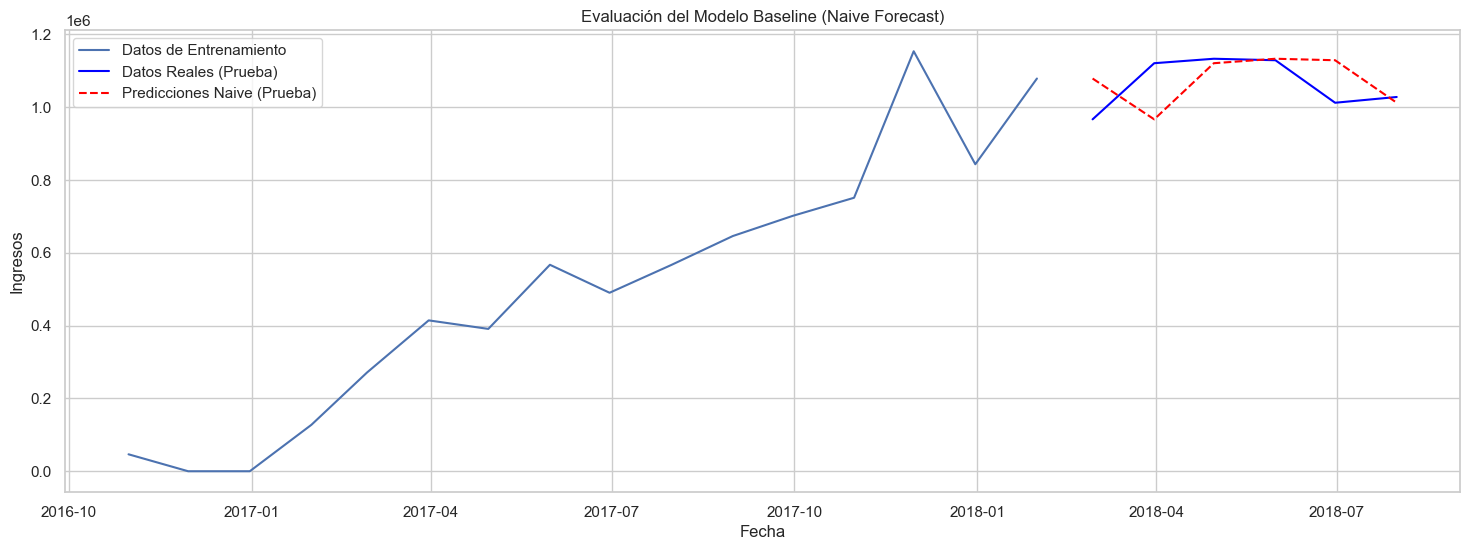

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calcular métricas de error
mae = mean_absolute_error(test_data, predictions_naive)
mse = mean_squared_error(test_data, predictions_naive)
rmse = np.sqrt(mse)
safe_test = test_data.replace(0, np.nan)
mape = (np.abs((test_data - predictions_naive) / safe_test).dropna()).mean() * 100
forecast_bias = (predictions_naive - test_data).mean()

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:,.2f}%")
print(f"Forecast Bias (media de errores): {forecast_bias:,.2f}")

# Visualización de los resultados
plt.figure(figsize=(18, 6))
plt.plot(train_data.index, train_data, label='Datos de Entrenamiento')
plt.plot(test_data.index, test_data, label='Datos Reales (Prueba)', color='blue')
plt.plot(predictions_naive.index, predictions_naive, label='Predicciones Naive (Prueba)', color='red', linestyle='--')
plt.title('Evaluación del Modelo Baseline (Naive Forecast)')
plt.xlabel('Fecha')
plt.ylabel('Ingresos')
plt.legend()
plt.show()

### Conclusión de la Evaluación del Baseline
El modelo Naive sigue la tendencia general, pero no captura las fluctuaciones (picos y valles) dentro del período de prueba. El RMSE de `X` nos da una idea de la magnitud del error promedio en unidades de ingreso.

Cualquier modelo más avanzado que desarrollemos (como ARIMA, Prophet, o modelos de Machine Learning) deberá superar este RMSE para ser considerado útil. Este es nuestro **punto de referencia**.

---

## Próximos Pasos (Sprint 2)
- **Modelos Avanzados:** Implementar modelos como SARIMA (que considera la estacionalidad) o Facebook Prophet.
- **Ingeniería de Características Adicional:** Incluir variables exógenas como festividades o campañas de marketing.
- **Optimización de Hiperparámetros:** Ajustar los parámetros de los modelos para minimizar el error.
- **Validación Cruzada para Series Temporales:** Utilizar técnicas de validación más robustas.

## 8. Métricas de Negocio Baseline
Calculamos indicadores iniciales para monitorear impacto comercial y de experiencia de cliente:
- **Retención mensual:** porcentaje de clientes que realizan una recompra en meses consecutivos.
- **Tiempo de entrega promedio y cumplimiento:** días promedio más % de órdenes entregadas a tiempo.
- **Satisfacción del cliente:** puntaje promedio de reviews y proxy de NPS.
- **Ticket promedio por tipo de pago:** referencia para pricing y campañas.

In [30]:
# Métricas de negocio baseline
# 1) Retención mensual
master_table['order_month_period'] = master_table['order_month'].apply(lambda x: pd.Period(x, freq='M'))
delivered_orders = master_table[master_table['is_delivered'] == 1].copy()
delivered_orders = delivered_orders.sort_values('order_month_period')

customers_by_month = delivered_orders.groupby('order_month_period')['customer_unique_id'].apply(set)
retention_rows = []
previous_month = None
for month, customers_set in customers_by_month.items():
    if previous_month is not None:
        prev_set = customers_by_month[previous_month]
        if prev_set:
            retained = len(customers_set & prev_set)
            retention_rate = retained / len(prev_set)
        else:
            retention_rate = np.nan
        retention_rows.append({'month': month.to_timestamp(), 'retention_rate': retention_rate})
    previous_month = month

retention_df = pd.DataFrame(retention_rows)
avg_retention_rate = retention_df['retention_rate'].mean() * 100 if not retention_df.empty else np.nan

# 2) Tiempos de entrega
avg_delivery_time = delivered_orders['delivery_time_days'].mean()
on_time_rate = delivered_orders['delivered_on_time'].mean() * 100

# 3) Satisfacción (reviews)
reviews_scores = delivered_orders['review_score_mean'].dropna()
avg_review_score = reviews_scores.mean()
nps_proxy = (
    (reviews_scores[reviews_scores >= 4].count() / reviews_scores.count()) -
    (reviews_scores[reviews_scores <= 2].count() / reviews_scores.count())
) * 100 if reviews_scores.count() > 0 else np.nan

# 4) Ticket promedio por tipo de pago
avg_ticket_by_payment = delivered_orders.groupby('primary_payment_type')['payment_total'].mean().sort_values(ascending=False)

print(f"Retención promedio (mes a mes): {avg_retention_rate:.2f}%")
print(f"Tiempo de entrega promedio: {avg_delivery_time:.2f} días")
print(f"% entregas a tiempo: {on_time_rate:.2f}%")
print(f"Review score promedio: {avg_review_score:.2f}")
print(f"Proxy NPS: {nps_proxy:.2f} puntos")

if not retention_df.empty:
    display(retention_df.tail())

print("\nTicket promedio por tipo de pago (top 5):")
avg_ticket_by_payment.head(5)

Retención promedio (mes a mes): 4.99%
Tiempo de entrega promedio: 12.09 días
% entregas a tiempo: 93.22%
Review score promedio: 4.16
Proxy NPS: 66.15 puntos


,month,retention_rate
17,2018-04-01,0.004484
18,2018-05-01,0.006673
19,2018-06-01,0.005678
20,2018-07-01,0.004290
21,2018-08-01,0.006066



Ticket promedio por tipo de pago (top 5):


primary_payment_type
credit_card    165.439408
boleto         144.334979
debit_card     140.411806
voucher        113.596346
Name: payment_total, dtype: float64

## 9. Consideraciones adicionales para completar el Sprint 1
- Documentar el diccionario de datos (60+ metadatos) en un repositorio compartido y versionado.
- Definir chequeos automáticos de calidad (validación de duplicados, fechas fuera de rango, outliers críticos).
- Integrar el pipeline con un dashboard (Power BI, Looker) que exponga ingresos, retención y satisfacción.
- Alinear con Finanzas el calendario de cierre para que el corte mensual coincida con el reporting corporativo.
- Establecer OKRs y metas objetivo (ej. reducir tiempo de entrega en 10%, elevar retención a 28%).
- Preparar un backlog de modelos avanzados (SARIMA, Prophet, Gradient Boosting) con criterios de comparación sobre el baseline actual.

## Apéndice A: Validación de la Fuente de Ingresos (Pagos vs Items)
Comprobamos que utilizar `payment_value` como ingreso por orden es adecuado para el total mensual. Contrastamos con la suma de `price + freight_value` a nivel de orden y evaluamos diferencias.

Órdenes comparadas: 98,665
Coincidencia exacta pagos vs items (tolerancia ~0): 99.42%
Correlación pagos vs items: 1.0000

Distribución de diferencias (payments - items):
count    98665.000000
mean         0.029092
std          1.129221
min        -51.620000
25%          0.000000
50%          0.000000
75%          0.000000
max        182.810000
Name: diff, dtype: float64


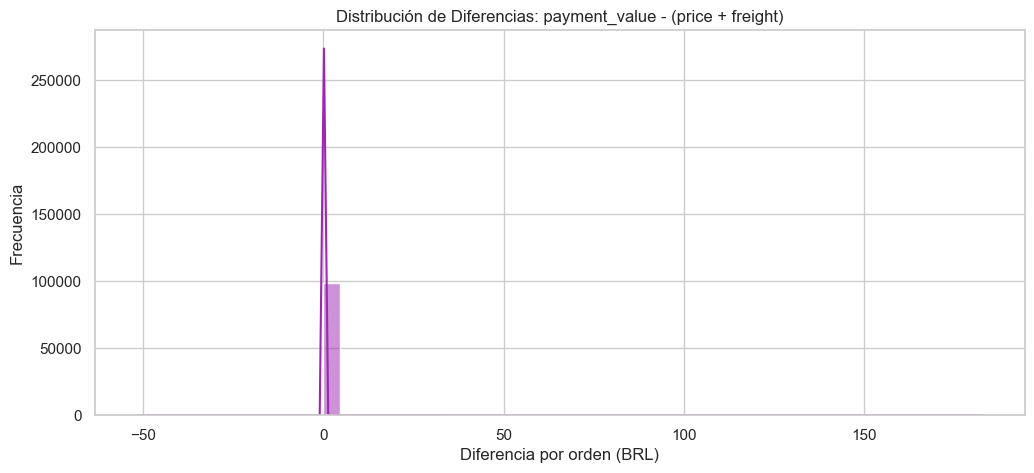

In [15]:
# Agregar pagos por orden y items por orden para comparar
payments_agg_check = payments.groupby('order_id', as_index=False)['payment_value'].sum().rename(columns={'payment_value':'payments_total'})
items_agg_check = items.groupby('order_id', as_index=False)[['price','freight_value']].sum()
items_agg_check['items_total'] = items_agg_check['price'] + items_agg_check['freight_value']

cmp = pd.merge(payments_agg_check, items_agg_check[['order_id','items_total']], on='order_id', how='inner')
cmp['diff'] = cmp['payments_total'] - cmp['items_total']

match_rate = (cmp['diff'].abs() < 1e-6).mean()*100
corr = cmp[['payments_total','items_total']].corr().iloc[0,1]

print(f"Órdenes comparadas: {len(cmp):,}")
print(f"Coincidencia exacta pagos vs items (tolerancia ~0): {match_rate:.2f}%")
print(f"Correlación pagos vs items: {corr:.4f}")
print("\nDistribución de diferencias (payments - items):")
print(cmp['diff'].describe())

plt.figure(figsize=(12,5))
sns.histplot(cmp['diff'], bins=50, kde=True, color='#9C27B0')
plt.title('Distribución de Diferencias: payment_value - (price + freight)')
plt.xlabel('Diferencia por orden (BRL)')
plt.ylabel('Frecuencia')
plt.show()

# Nota: Pagos pueden incluir redondeos, cuotas, y ajustes no reflejados en items. Para ingresos contables, payments es la fuente de verdad.


## Apéndice B: Exploración de CSVs adicionales (con datos)
Cargamos otros CSVs para mostrar su estructura y posibles usos futuros, y por qué no son estrictamente necesarios para el objetivo de ingresos mensuales agregados.

In [16]:
# Cargar CSVs adicionales
products = pd.read_csv('olist_products_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

print("Products:")
print(products.head())
print("\nProduct Category Translations:")
print(translation.head())
print("\nSellers:")
print(sellers.head())
print("\nReviews:")
print(reviews.head())
print("\nGeolocation:")
print(geolocation.head())

print("\nFormas y tamaños:")
print({
    'products': products.shape,
    'translation': translation.shape,
    'sellers': sellers.shape,
    'reviews': reviews.shape,
    'geolocation': geolocation.shape,
})

Products:
                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            100

### Ejemplo: Ingresos por Categoría de Producto (para análisis futuro)
Aunque no es necesario para el total mensual, mostramos cómo analizar categorías para decisiones comerciales.

In [ ]:
# Proxy de ingresos por categoría: suma de price por categoría
items_products = pd.merge(items, products[['product_id','product_category_name']], on='product_id', how='left')
items_products = pd.merge(items_products, translation, on='product_category_name', how='left')

cat_revenue = items_products.groupby('product_category_name_english', dropna=False)['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
cat_revenue.plot(kind='bar', color='#607D8B')
plt.title('Top 10 Categorías por Ingreso (proxy: suma de price)')
plt.xlabel('Categoría')
plt.ylabel('Suma de price (proxy de ingresos)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Nota: aquí usamos price como proxy de ingresos por categoría. Para ingresos contables totales usamos payments.")